Dataset: https://drive.google.com/file/d/1ZgqFJomqQGNnsx7w7QBzQQMVA16lbVCA/view

## import stuffs here &rarr;

In [21]:
import os
import xml.etree.ElementTree as ET
import numpy as np
import cv2
from PIL import Image
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader
import random
import albumentations as A
from albumentations.pytorch import ToTensorV2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## building the U-Net Attention Architecture:

#### architecture of U-Net: 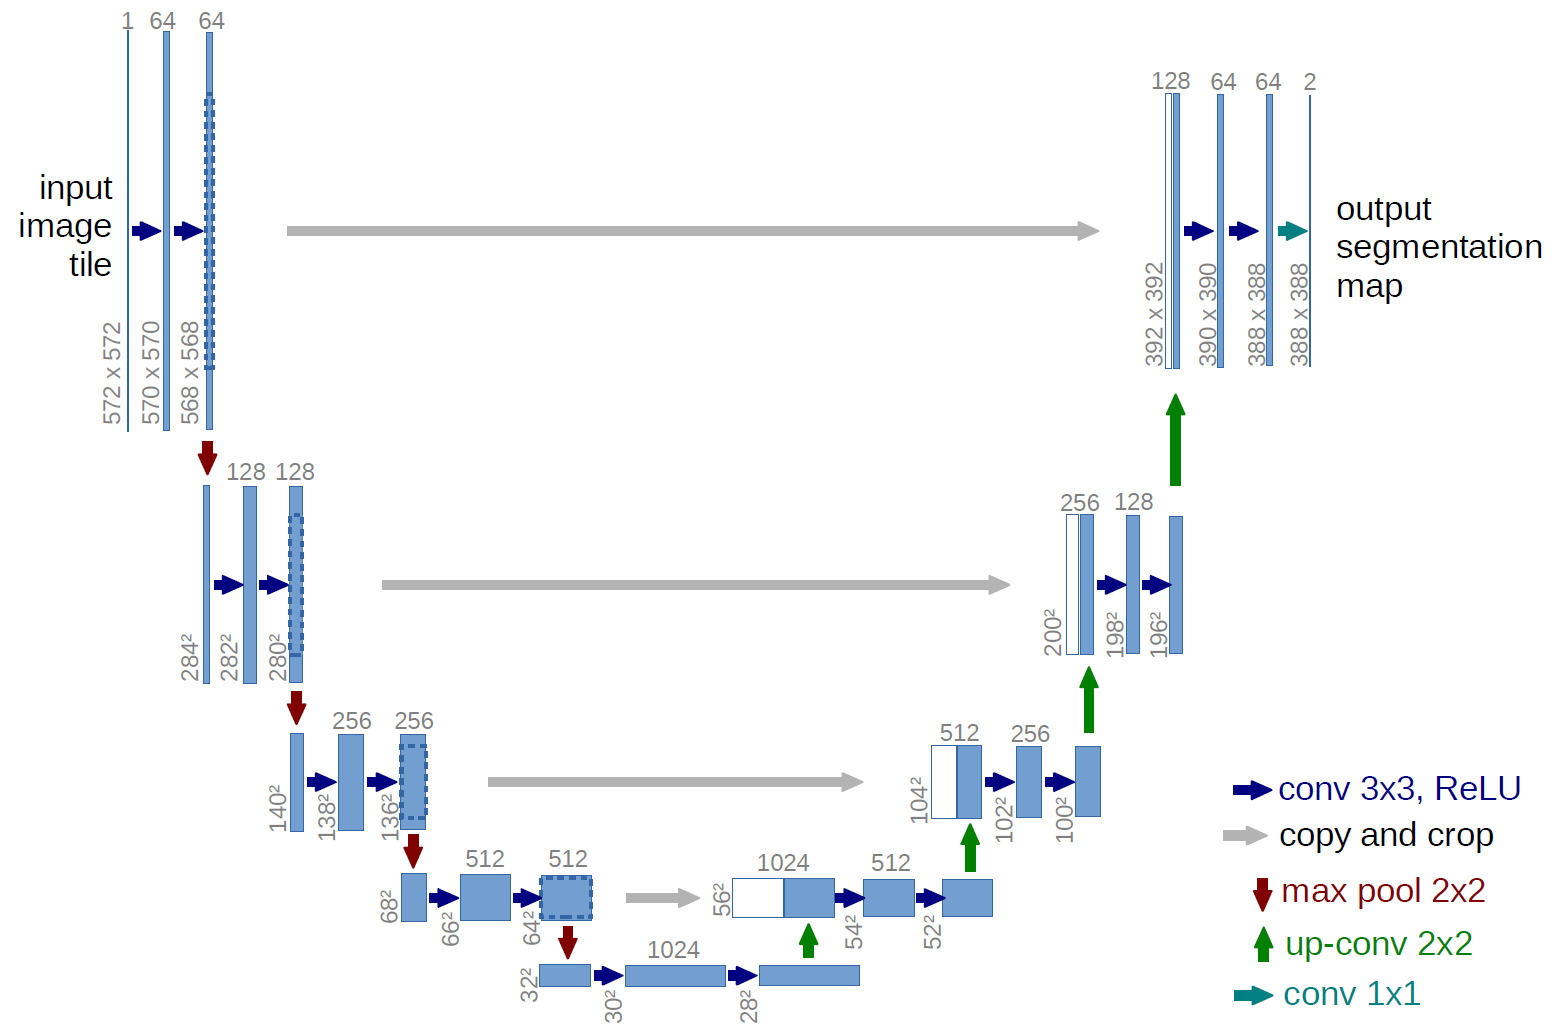
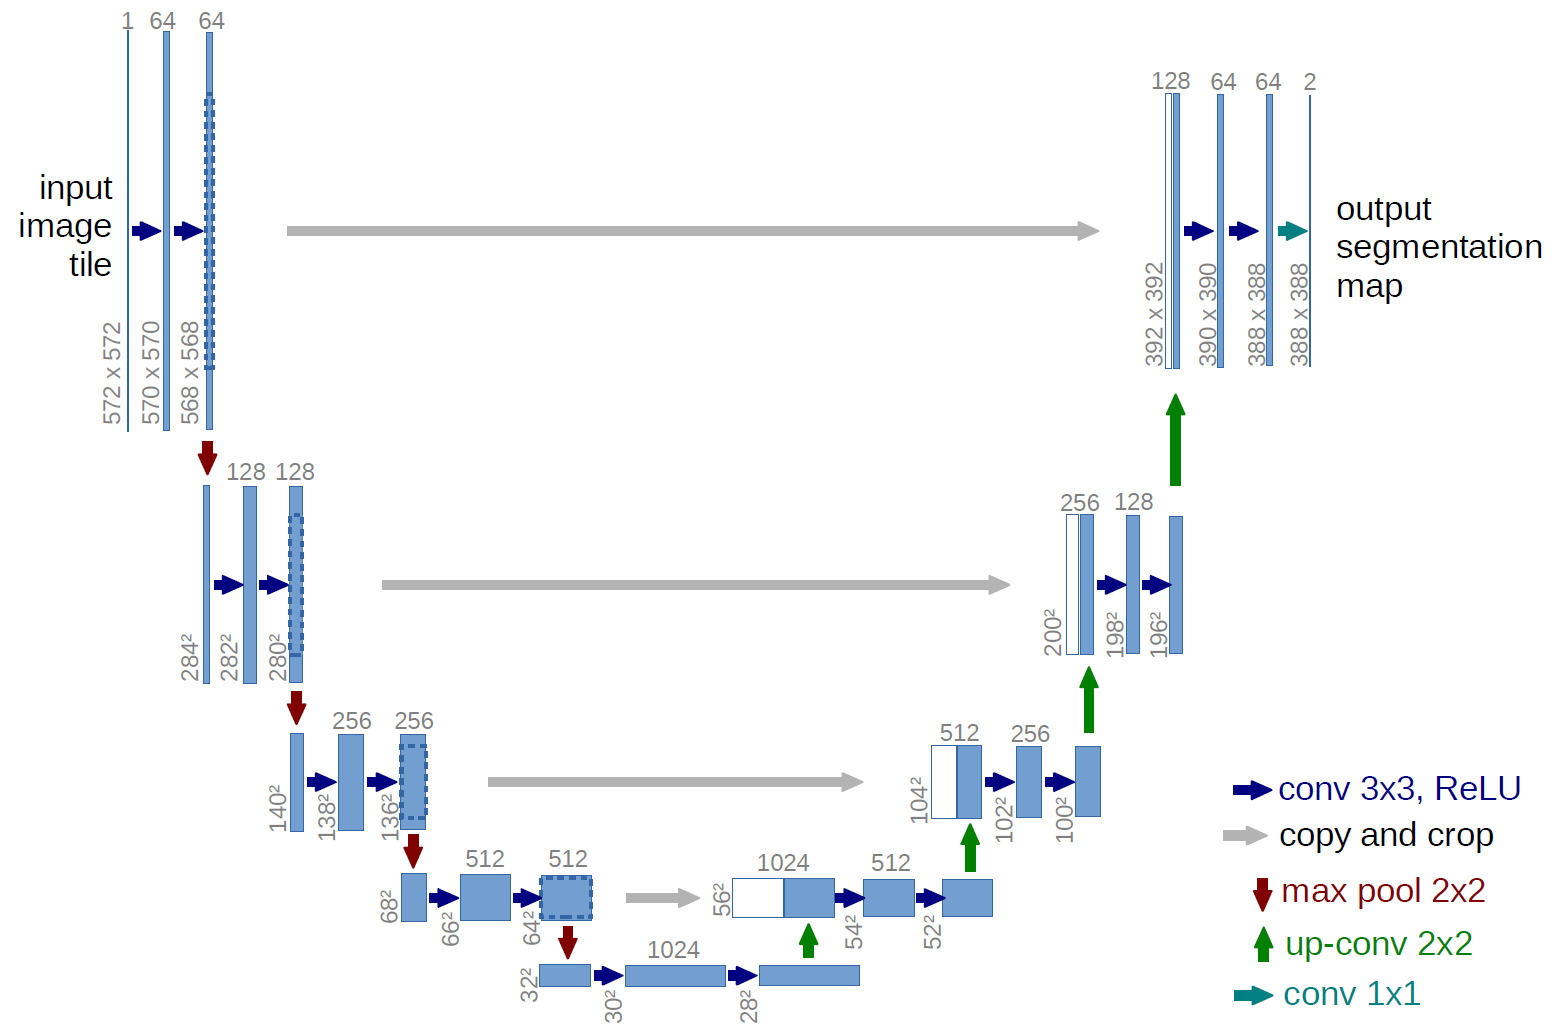
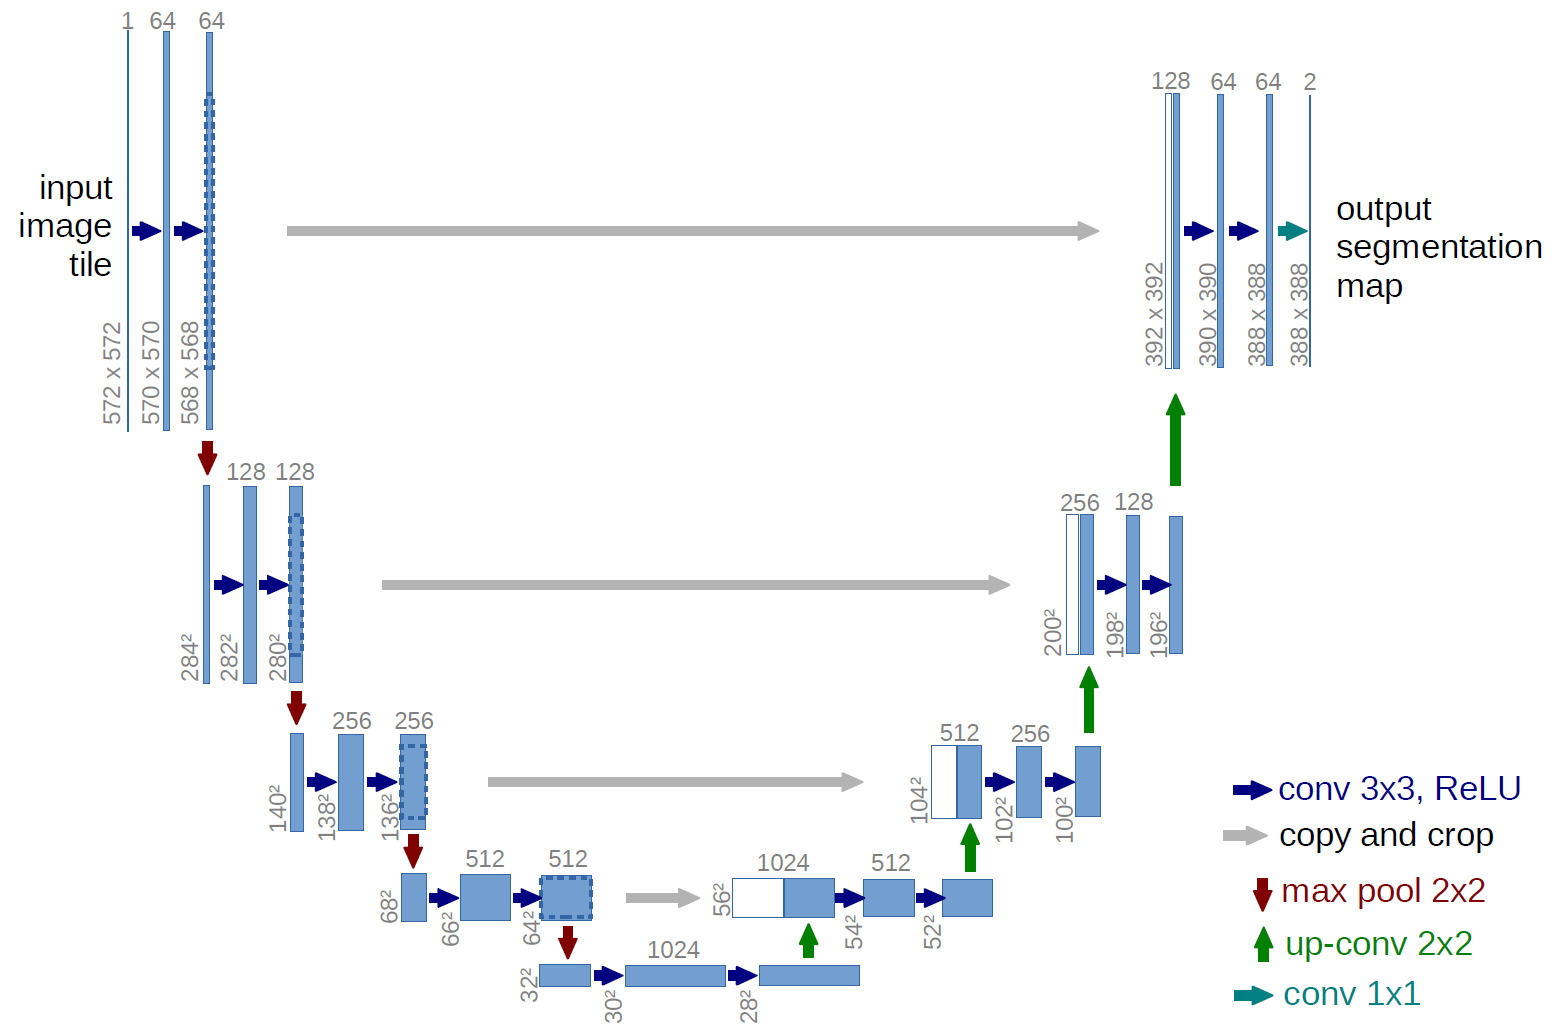
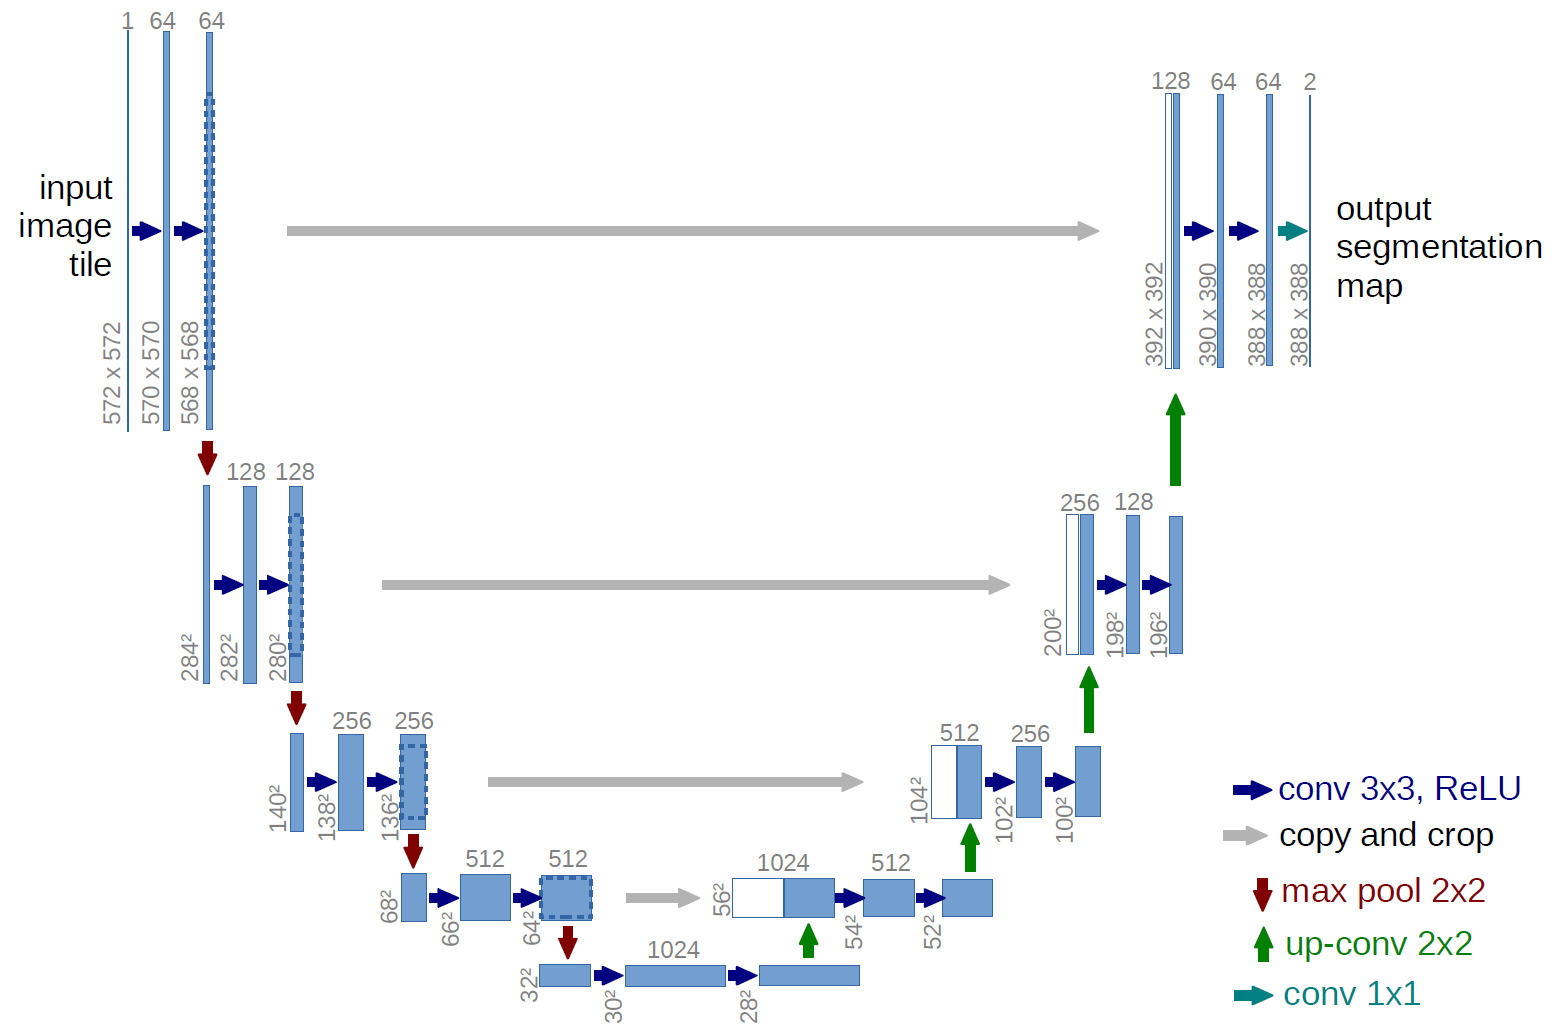

Attention U-Net 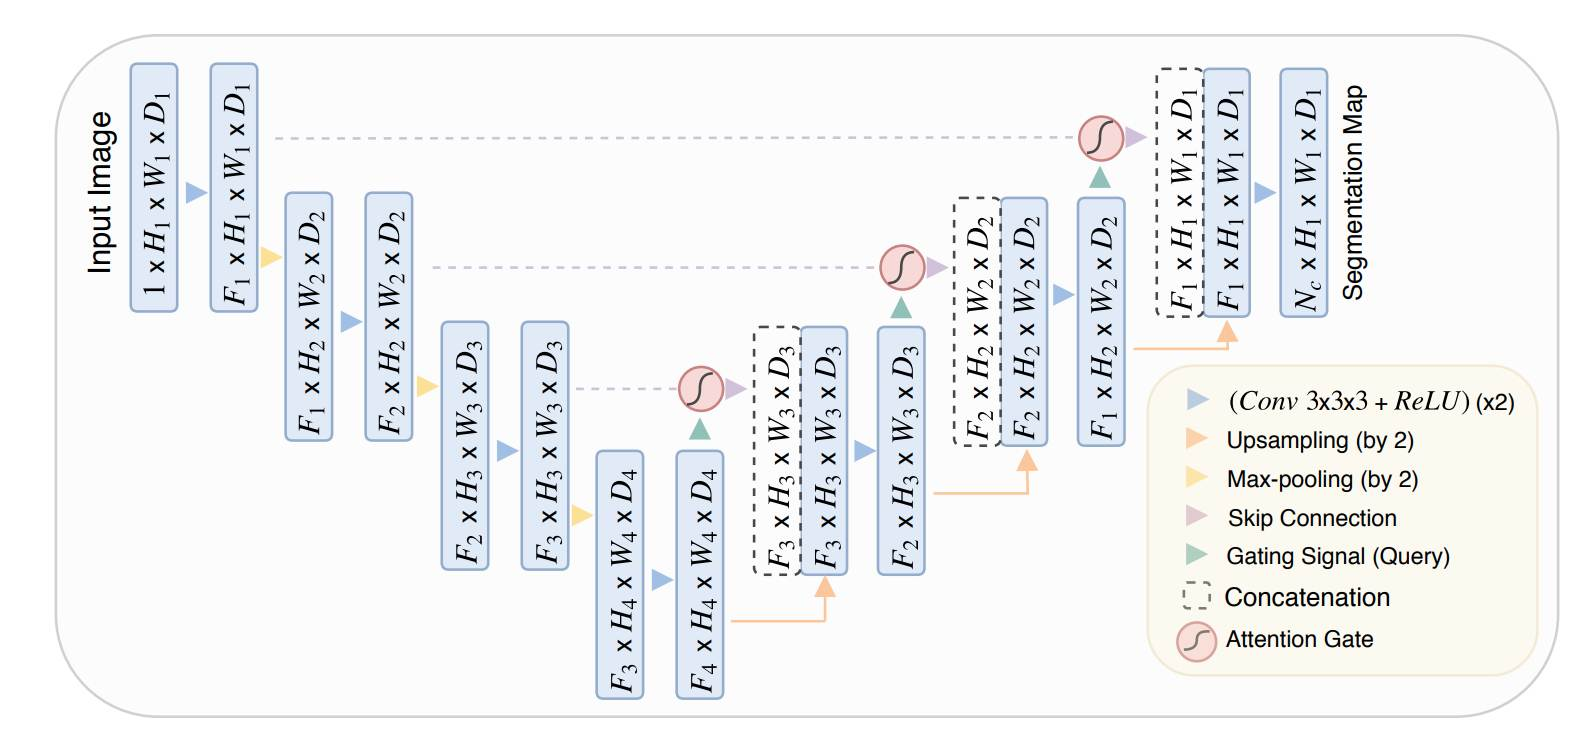
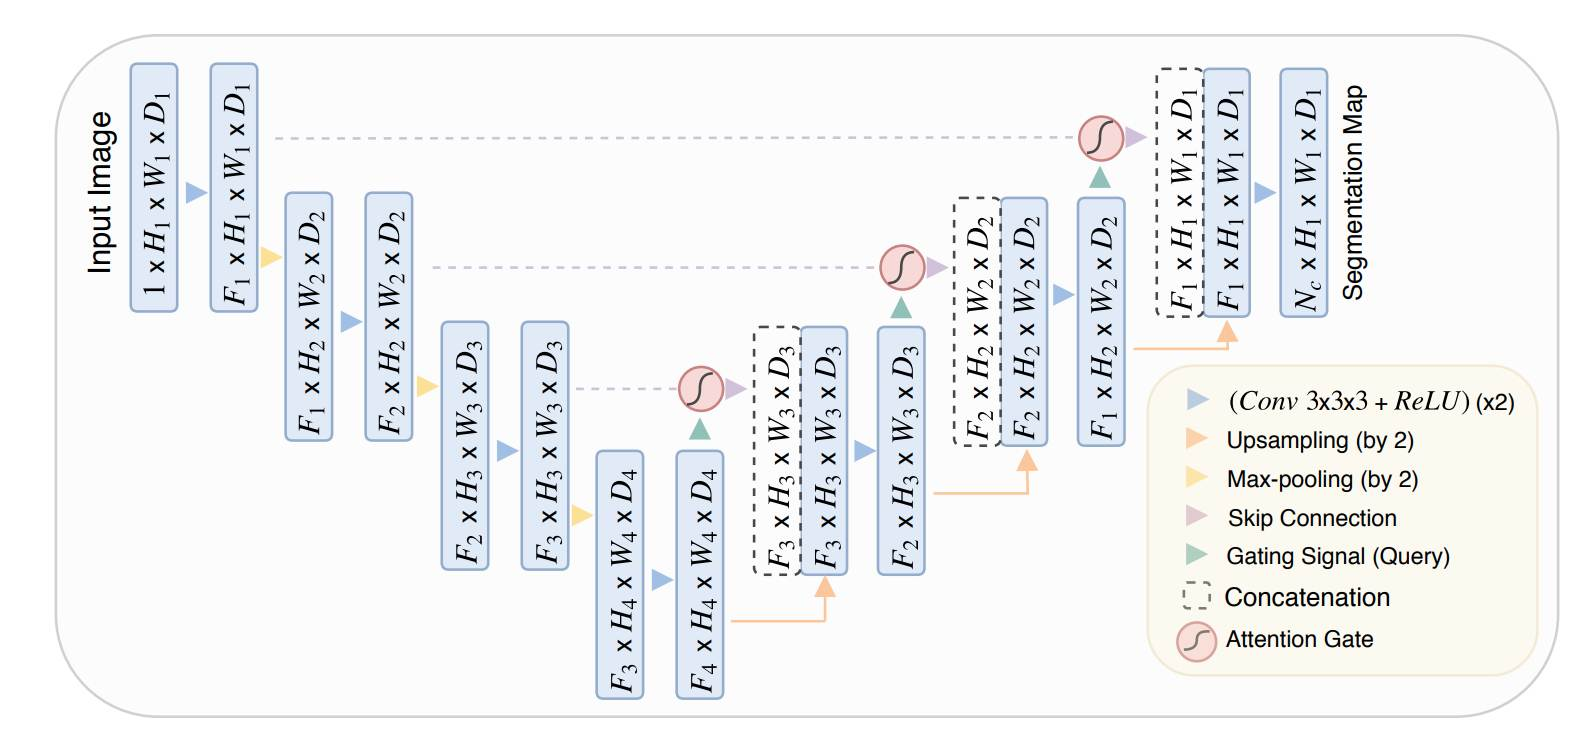


#### Creating the classes 

DoubleConv

In [3]:
class doubleConv(nn.Module):
    def __init__(self , input_ch , output_ch):
        super().__init__()
        self.conv1 = nn.Conv2d(input_ch , output_ch , 3) #no padding
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(output_ch , output_ch , 3) #no padding
    def forward(self , x):
        return self.relu(self.conv2(self.relu(self.conv1(x))))



Attention Gate

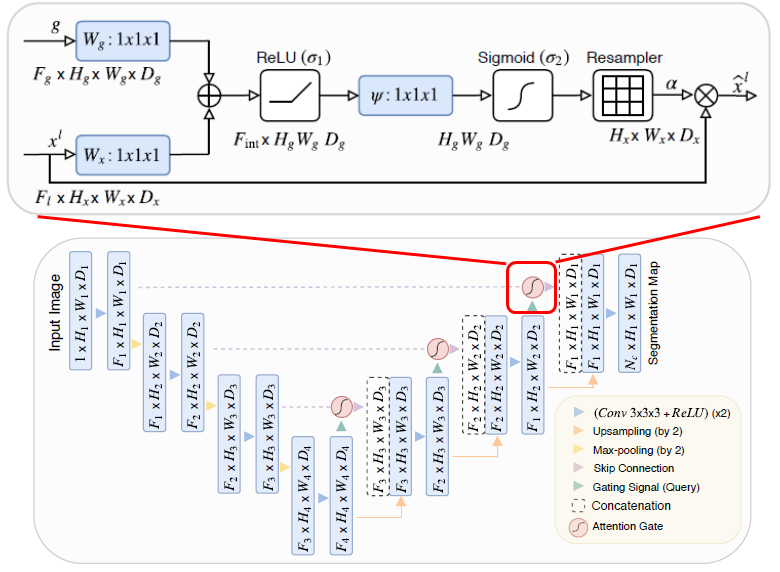
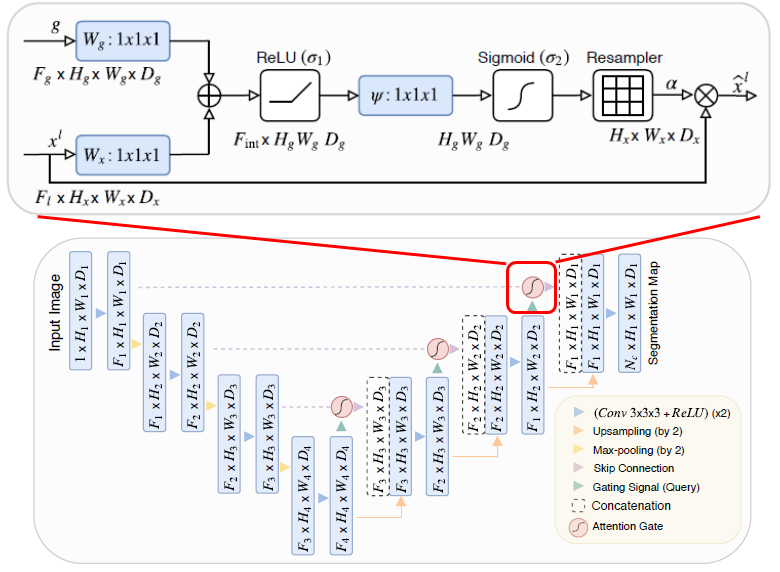

code:

In [8]:
class AttentionGate(nn.Module):
    """
        F_g: Channels in the gating signal (Decoder feature map)
        F_l: Channels in the skip connection (Encoder feature map)
        F_int: Intermediate channels for the 1x1 convolutions
    """
    def __init__(self, F_g , F_l , F_int):
        super().__init__()
        self.W_g = nn.Conv2d(F_g , F_int , 1) #W_g block
        self.W_x = nn.Conv2d(F_l , F_int , 1) #W_l block
        self.psi = nn.Conv2d(F_int , 1,1) #psi block
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, g , x):
        g1 = self.W_g(g) # F_int × H_g × W_g
        x1 = self.W_x(x) # F_int × H_g × W_g
        psi = self.relu(g1 + x1) # @ then relu
        psi = self.sigmoid(self.psi(psi)) # psi then sigmoid → 1 × H × W
        return x*psi

Encoder

In [9]:
class Encoder(nn.Module):
    def __init__(self, chs = (3,64,128,256,512,1024)):
        super().__init__()
        self.enc_blocks = nn.ModuleList(
            [doubleConv(chs[i] , chs[i+1]) for i in range(len(chs) -1)]
            # this is the list of the double convolution operation we defined above
        )
        self.pool = nn.MaxPool2d(2)
    def forward(self,x):
        ftrs = [] #collects output of each block before pooling, this is the skip connecttion
        for block in self.enc_blocks:
            x = block(x)
            ftrs.append(x)
            x = self.pool(x)
        return ftrs

Decoder

In [10]:
class Decoder(nn.Module):
    def __init__(self , chs = (1024, 512 , 256 , 128 , 64 )):
        super().__init__()
        self.chs = chs
        self.upconvs = nn.ModuleList(
            [nn.ConvTranspose2d(chs[i],chs[i+1],2,2) for i in range(len(self.chs)-1)]
        )
        self.attention_gates = nn.ModuleList(            
            [AttentionGate(chs[i+1], chs[i+1], chs[i+1]//2) for i in range(len(self.chs)-1)]
        )
        self.dec_blocks = nn.ModuleList(
            [doubleConv(chs[i],chs[i+1]) for i in range(len(self.chs)-1)]
        )
    def forward(self,x,encoder_features):
        for i in range(len(self.chs) -1):
            x = self.upconvs[i](x) #doubles the H,W halves channels
            enc_features = self.crop(encoder_features[i] , x) #crop to match x's H,W
            enc_features = self.attention_gates[i](g=x, x=enc_features)  # new (g=decoder query, x=encoder keys)
            x = torch.cat([x , enc_features] , dim = 1) #channel doubles again
            x = self.dec_blocks[i](x) 
        return x
    def crop(self, enc_features , x):
        _ , _ , H , W = x.shape
        cropper = torchvision.transforms.CenterCrop([H,W])
        enc_features = cropper(enc_features)
        return enc_features

implenting model

In [11]:
class UNet(nn.Module):
    def __init__(self, enc_chs=(3,64,128,256,512,1024), dec_chs=(1024, 512, 256, 128, 64), num_class=1):
        super().__init__()
        self.encoder = Encoder(enc_chs)
        self.decoder = Decoder(dec_chs)
        self.head = nn.Conv2d(dec_chs[-1], num_class , 1)
    def forward(self,x):
        enc_ftrs = self.encoder(x)
        out = self.decoder(enc_ftrs[::-1][0],enc_ftrs[::-1][1:])
        #self.decoder(bottleneck, [skip connections])
        out = self.head(out) #final 1×1 conv 
        return out

## Dataset management :)

In [15]:
import torch
from torch.utils.data import Dataset

class MoNuSegDataset(torch.utils.data.Dataset):
    def __init__(self, image_dir, mask_dir, is_train=True, crop_size=572):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.filenames = sorted(os.listdir(image_dir))

        if is_train:
            self.transform = A.Compose([
                A.RandomCrop(crop_size, crop_size),
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.5),
                A.RandomRotate90(p=0.5),
                ToTensorV2()
            ])
        else:
            self.transform = A.Compose([
                A.CenterCrop(crop_size, crop_size),
                ToTensorV2()
            ])

    def __len__(self):
        return len(self.filenames)
    
    def __getitem__(self, idx):
        base = os.path.splitext(self.filenames[idx])[0]

        image_path = os.path.join(self.image_dir, f"{base}.png")
        mask_path = os.path.join(self.mask_dir, f"{base}.png")

        image = np.array(Image.open(image_path).convert("RGB"))       # (H,W,3) uint8
        mask  = np.array(Image.open(mask_path).convert("L"))          # (H,W) uint8

        augmented = self.transform(image=image, mask=mask)
        image_tensor = augmented["image"].float() / 255.0   # (3,572,572) float 0-1
        mask_tensor  = augmented["mask"].float()  / 255.0   # (572,572) float 0-1
        mask_tensor  = (mask_tensor > 0.5).float().unsqueeze(0) # (1,572,572) binary float tensor

        return image_tensor, mask_tensor


In [26]:
# Kaggle Input paths
TRAIN_IMG_DIR  = "/kaggle/input/datasets/momoketchum/monuseg-2018/data/train/images"
TRAIN_MASK_DIR = "/kaggle/input/datasets/momoketchum/monuseg-2018/data/train/masks"
VAL_IMG_DIR    = "/kaggle/input/datasets/momoketchum/monuseg-2018/data/val/images"
VAL_MASK_DIR   = "/kaggle/input/datasets/momoketchum/monuseg-2018/data/val/masks"

# Initialize datasets with Kaggle paths (Option A: 572x572 crops for U-Net)
train_ds = MoNuSegDataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, is_train=True, crop_size=572)
val_ds   = MoNuSegDataset(VAL_IMG_DIR,   VAL_MASK_DIR,   is_train=False, crop_size=572)

# Initialize Loaders (keep num_workers=2 since Kaggle VMs support multiprocessing)
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=2, shuffle=False, num_workers=2, pin_memory=True)

print(f"train samples: {len(train_ds)} | val samples: {len(val_ds)}")

# Quick shape check
imgs, masks = next(iter(train_loader))
print(f"image batch shape: {imgs.shape}")  # Expected: (2, 3, 572, 572)
print(f"mask batch shape:  {masks.shape}") # Expected: (2, 1, 572, 572)



train samples: 26 | val samples: 11
image batch shape: torch.Size([4, 3, 572, 572])
mask batch shape:  torch.Size([4, 1, 572, 572])


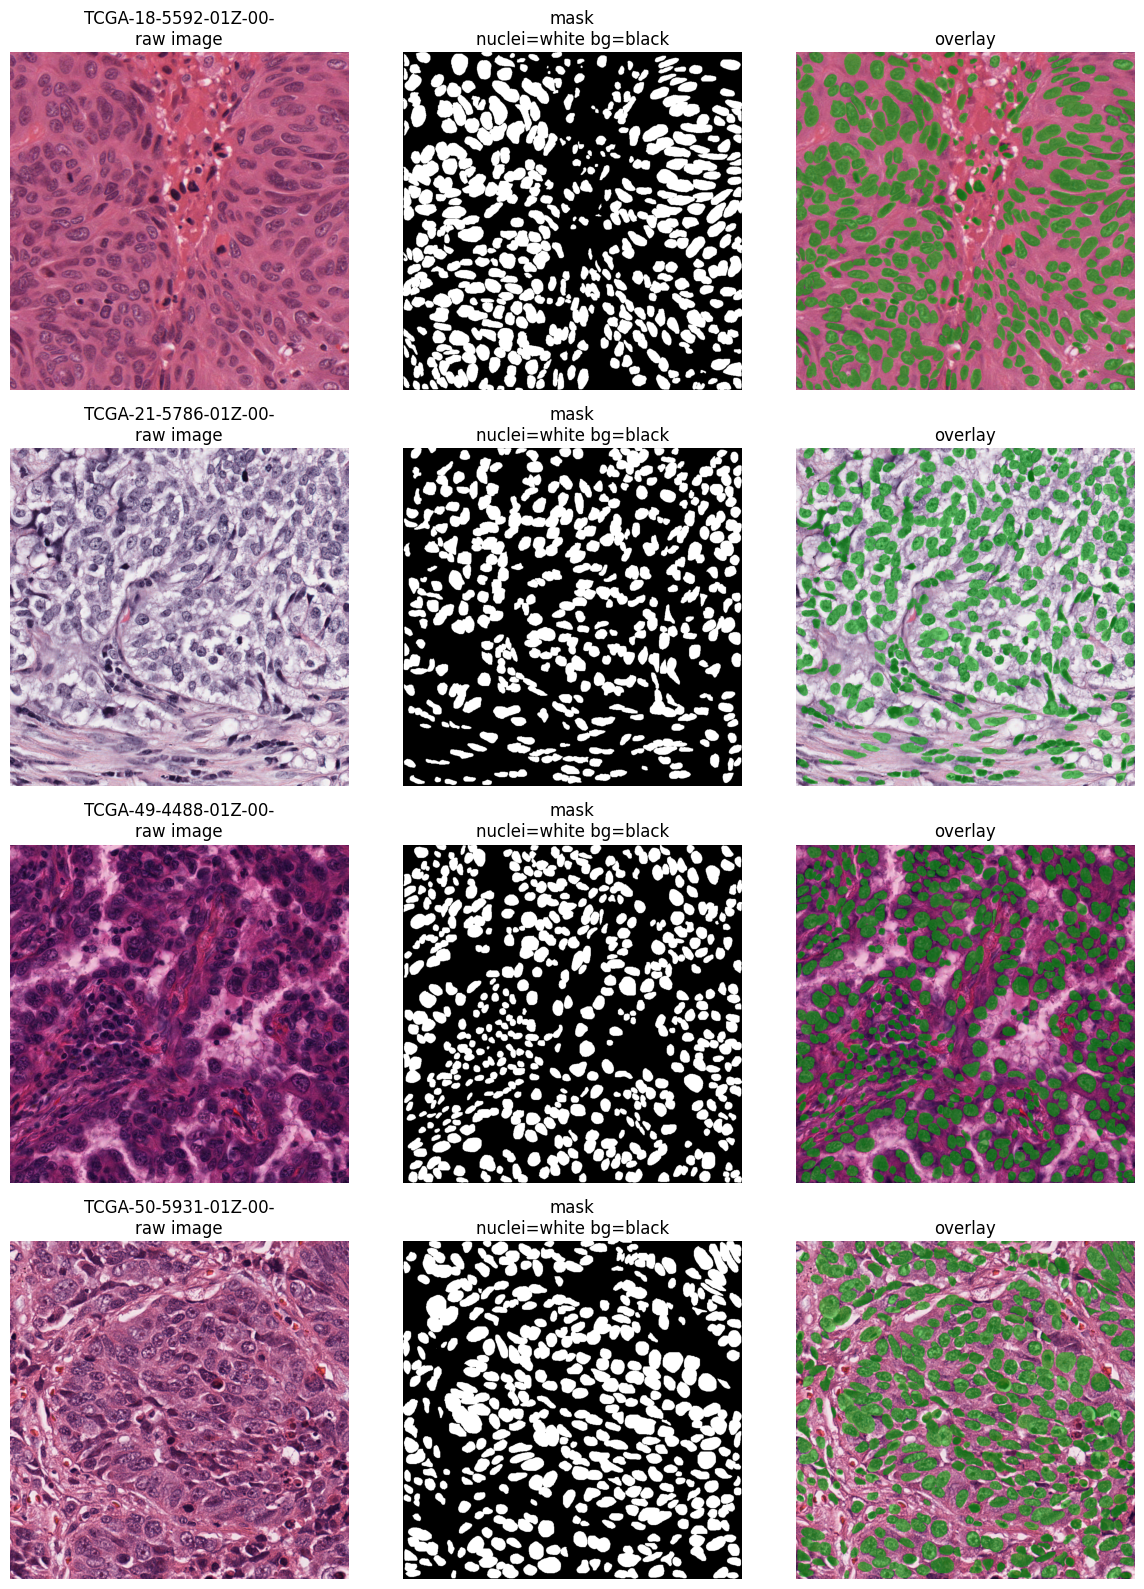

saved to visualise_train.png


In [23]:
def visualise_samples(split="train", n=4):
    # Dynamic paths based on train/val split
    img_dir  = f"/kaggle/input/datasets/momoketchum/monuseg-2018/data/{split}/images"
    mask_dir = f"/kaggle/input/datasets/momoketchum/monuseg-2018/data/{split}/masks"
    files    = sorted(os.listdir(img_dir))[:n]

    fig, axes = plt.subplots(n, 3, figsize=(12, n*4))

    for i, fname in enumerate(files):
        base = os.path.splitext(fname)[0]
        img  = np.array(Image.open(os.path.join(img_dir,  f"{base}.png")))
        mask = np.array(Image.open(os.path.join(mask_dir, f"{base}.png")))

        # overlay: green tint on nuclei
        overlay = img.copy()
        overlay[mask > 127] = (overlay[mask > 127] * 0.5 + np.array([0, 200, 0]) * 0.5).astype(np.uint8)

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"{base[:20]}\nraw image")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask, cmap="gray")
        axes[i, 1].set_title("mask\nnuclei=white bg=black")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title("overlay")
        axes[i, 2].axis("off")

    plt.tight_layout()
    # Saves output in Kaggle's working directory /kaggle/working
    plt.savefig(f"./visualise_{split}.png", dpi=100)
    plt.show()
    print(f"saved to visualise_{split}.png")

# Run it
visualise_samples("train", n=4)


── train split ──
total images   : 26
image sizes    : {(1000, 1000)}
fg ratio       : min=0.119  max=0.427  mean=0.275
nuclei per img : min=179  max=1026  mean=491.6


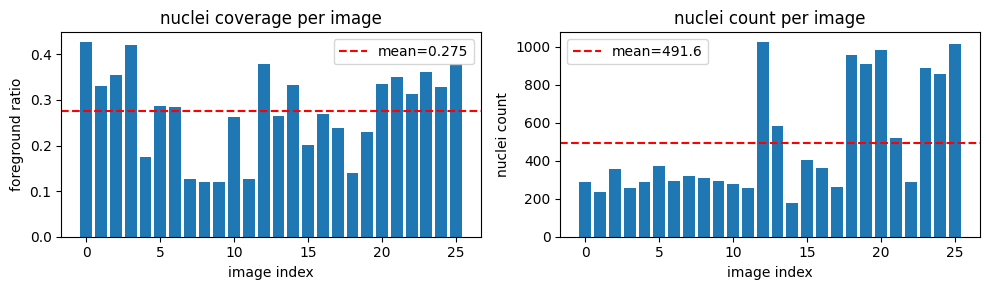

── val split ──
total images   : 11
image sizes    : {(1000, 1000)}
fg ratio       : min=0.138  max=0.419  mean=0.249
nuclei per img : min=159  max=945  mean=422.5


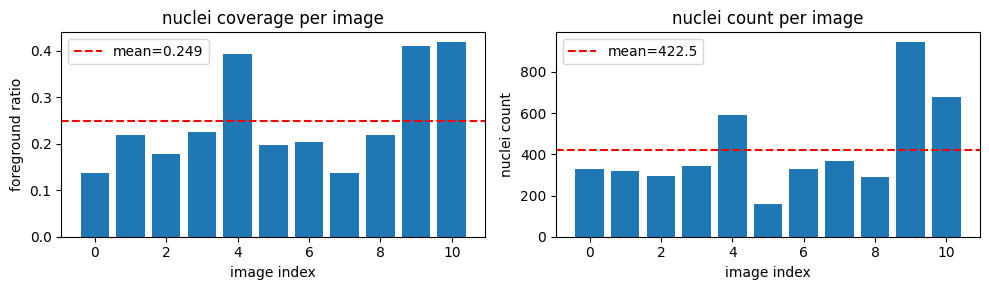

In [28]:
def dataset_stats(split="train"):
    # Dynamic paths based on train/val split
    img_dir  = f"/kaggle/input/datasets/momoketchum/monuseg-2018/data/{split}/images"
    mask_dir = f"/kaggle/input/datasets/momoketchum/monuseg-2018/data/{split}/masks"
    
    # Load all files in the split
    files = sorted(os.listdir(img_dir))

    sizes, nuclei_counts, fg_ratios = [], [], []

    for fname in files:
        base = os.path.splitext(fname)[0]
        img  = np.array(Image.open(os.path.join(img_dir,  f"{base}.png")))
        mask = np.array(Image.open(os.path.join(mask_dir, f"{base}.png")))

        sizes.append(img.shape[:2])

        # foreground ratio (how much of image is nuclei)
        fg = (mask > 127).sum() / mask.size
        fg_ratios.append(fg)

        # rough nucleus count via connected components
        binary = (mask > 127).astype(np.uint8)
        num_labels, _ = cv2.connectedComponents(binary)
        nuclei_counts.append(num_labels - 1)  # subtract background label

    print(f"── {split} split ──")
    print(f"total images   : {len(files)}")
    print(f"image sizes    : {set(map(tuple, sizes))}")
    print(f"fg ratio       : min={min(fg_ratios):.3f}  max={max(fg_ratios):.3f}  mean={np.mean(fg_ratios):.3f}")
    print(f"nuclei per img : min={min(nuclei_counts)}  max={max(nuclei_counts)}  mean={np.mean(nuclei_counts):.1f}")

    # plot fg ratio distribution
    plt.figure(figsize=(10, 3))
    plt.subplot(1, 2, 1)
    plt.bar(range(len(fg_ratios)), fg_ratios)
    plt.axhline(np.mean(fg_ratios), color='red', linestyle='--', label=f"mean={np.mean(fg_ratios):.3f}")
    plt.xlabel("image index")
    plt.ylabel("foreground ratio")
    plt.title("nuclei coverage per image")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.bar(range(len(nuclei_counts)), nuclei_counts)
    plt.axhline(np.mean(nuclei_counts), color='red', linestyle='--', label=f"mean={np.mean(nuclei_counts):.1f}")
    plt.xlabel("image index")
    plt.ylabel("nuclei count")
    plt.title("nuclei count per image")
    plt.legend()

    plt.tight_layout()
    plt.savefig(f"./stats_{split}.png", dpi=100)
    plt.show()

# Run for both splits
dataset_stats("train")
dataset_stats("val")


setting up the loss:

personal references:\
Dice Loss: https://lathashreeh.medium.com/dice-coefficient-what-is-it-ff090ec97bda

In [29]:
import torch
import torch.nn as nn

class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=0.5):
        super().__init__()
        self.bce_weight = bce_weight
        self.bce_logits = nn.BCEWithLogitsLoss()

    def forward(self, pred_logits, target):
        # 1. compute BCE (using raw logits for stability)
        loss_bce = self.bce_logits(pred_logits, target)

        # 2. prepare tensors for Dice (probabilities between 0 and 1)
        pred_probs = torch.sigmoid(pred_logits)
        smooth     = 1e-6
        
        # 3. calculate components (Sum across H and W dimensions)
        # Intersection: Area where both pred and target are 1
        intersection = (pred_probs * target).sum(dim=(2, 3))
        
        # Total Area: Sum of all pixels in both masks
        pred_area    = pred_probs.sum(dim=(2, 3))
        target_area  = target.sum(dim=(2, 3))

        # 4. Dice Formula: 1 - (2 * Intersect) / (Total Area)
        dice_coeff = (2 * intersection + smooth) / (pred_area + target_area + smooth)
        loss_dice  = (1 - dice_coeff).mean()

        # 5. Weighted Combination
        total_loss = (self.bce_weight * loss_bce) + ((1 - self.bce_weight) * loss_dice)
        
        return total_loss

def dice_score(pred_logits, target):
    pred_hard = (torch.sigmoid(pred_logits) > 0.5).float()
    smooth    = 1e-6

    intersection = (pred_hard * target).sum(dim=(2, 3))
    total_area   = pred_hard.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
    
    score = (2 * intersection + smooth) / (total_area + smooth)
    return score.mean().item()


In [32]:
from tqdm import tqdm

# ── config ─────────────────────────────────────
EPOCHS    = 50
LR        = 1e-4
BATCH     = 2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# ── model, optimizer, loss ──────────────────────
model     = UNet().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
criterion = BCEDiceLoss()

# ── metric trackers ─────────────────────────────
history = {"train_loss": [], "val_loss": [], "val_dice": []}
best_dice = 0.0

# ── training loop ───────────────────────────────
for epoch in range(1, EPOCHS + 1):

    # train
    model.train()
    train_loss = 0.0

    with tqdm(train_loader, desc=f"epoch {epoch:02d}/{EPOCHS} [train]", leave=False) as pbar:
        for imgs, masks in pbar:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

            optimizer.zero_grad(set_to_none=True)
            preds = model(imgs)
            masks = TF.center_crop(masks, preds.shape[-2:])  # 572→388

            loss  = criterion(preds, masks)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
            optimizer.step()

            train_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

    # val
    model.eval()
    val_loss = 0.0
    val_dice = 0.0

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            preds       = model(imgs)
            masks       = TF.center_crop(masks, preds.shape[-2:])
            val_loss   += criterion(preds, masks).item()
            val_dice   += dice_score(preds, masks)

    train_loss /= len(train_loader)
    val_loss   /= len(val_loader)
    val_dice   /= len(val_loader)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_dice"].append(val_dice)

    print(f"epoch {epoch:02d}/{EPOCHS} | "
          f"train_loss: {train_loss:.4f} | "
          f"val_loss: {val_loss:.4f} | "
          f"val_dice: {val_dice:.4f}")

    if val_dice > best_dice:
        best_dice = val_dice
        torch.save(model.state_dict(), "best_attention_unet.pth")
        print(f"  ↑ best model saved (dice={best_dice:.4f})")

print(f"\ndone. best val dice: {best_dice:.4f}")

Using device: cuda


epoch 01/50 | train_loss: 0.6688 | val_loss: 0.6683 | val_dice: 0.0000
  ↑ best model saved (dice=0.0000)


epoch 02/50 | train_loss: 0.6612 | val_loss: 0.6636 | val_dice: 0.0000


epoch 03/50 | train_loss: 0.6544 | val_loss: 0.6541 | val_dice: 0.0000


epoch 04/50 | train_loss: 0.6428 | val_loss: 0.6261 | val_dice: 0.0000


...

epoch 46/50 | train_loss: 0.3152 | val_loss: 0.3083 | val_dice: 0.7706
  ↑ best model saved (dice=0.7706)


epoch 47/50 | train_loss: 0.2922 | val_loss: 0.3049 | val_dice: 0.7530


epoch 48/50 | train_loss: 0.3143 | val_loss: 0.2973 | val_dice: 0.7747
  ↑ best model saved (dice=0.7747)


epoch 49/50 | train_loss: 0.2903 | val_loss: 0.2981 | val_dice: 0.7723


epoch 50/50 | train_loss: 0.3024 | val_loss: 0.3125 | val_dice: 0.7675

done. best val dice: 0.7747


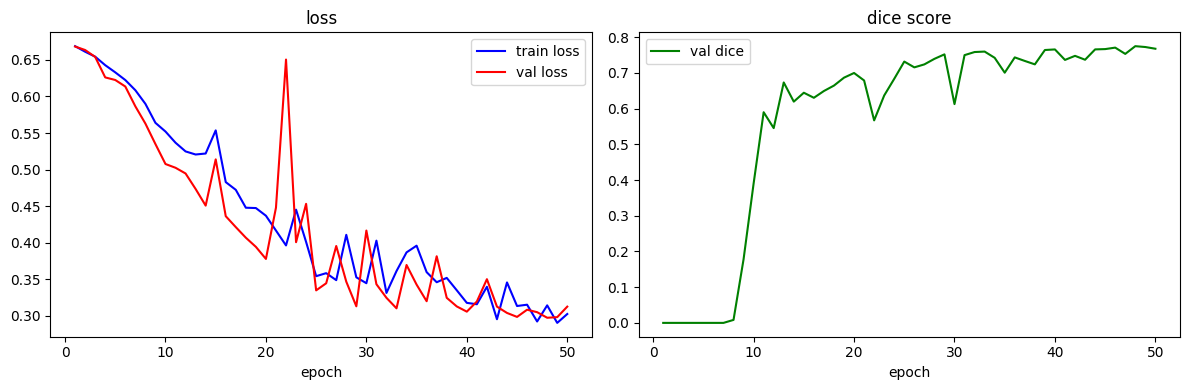

In [33]:
def plot_metrics(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, history["train_loss"], 'b', label='train loss')
    axes[0].plot(epochs, history["val_loss"],   'r', label='val loss')
    axes[0].set_title("loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()

    axes[1].plot(epochs, history["val_dice"], 'g', label='val dice')
    axes[1].set_title("dice score")
    axes[1].set_xlabel("epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=100)
    plt.show()

plot_metrics(history)
